# Rebuilding Micrograd with JAX — Understanding Neural Network Training

This notebook explores the core mechanics of how neural networks learn by recreating a minimal training system inspired by Karpathy’s micrograd project. The goal is to understand the fundamental components of machine learning systems by building them from first principles and then connecting those concepts to modern machine learning frameworks.

The original micrograd project demonstrates how automatic differentiation and backpropagation can be implemented manually to train neural networks. It focuses on educational clarity, showing how gradients flow through a computation graph and how parameters are updated during optimization.

In this notebook, we follow the same conceptual pipeline but implement the system using JAX. JAX provides powerful tools for automatic differentiation, vectorized computation, and just-in-time compilation. By replacing the manual autodiff engine with JAX primitives such as `jax.grad`, `jax.vmap`, and `jax.jit`, we can keep the mathematical learning process identical while using modern high-performance infrastructure.

The main intention of this notebook is to bridge two perspectives:

1. **Conceptual learning** — understanding how neural networks train internally through gradients, loss functions, and parameter updates.
2. **Practical implementation** — seeing how modern ML libraries automate these processes efficiently.

Through this project we build and explore the complete training pipeline of a neural network:

Data → Model → Prediction → Loss → Gradient → Parameter Update → Training Loop

We then compare two implementations of this process:

- A micrograd-style training approach that follows the conceptual structure used in educational implementations.
- A JAX-based implementation that leverages automatic differentiation and optimized computation.

By the end of this notebook, we gain a clear understanding of how neural networks learn and how foundational ideas translate directly into modern machine learning systems.

In [15]:
import jax
import jax.numpy  as jnp

In [16]:
# Create  Dataset :-

#inputs :- X
# expected output :- Y
X = jnp.array([[2.,3.],[1.,-1.],[3.,-4.],[0.25,-0.5]])
Y = jnp.array([-1.,1.,1.,-1.])

Let's Build the brain of the neural Network

normally ,
  A neural Network consists of


*   weights
*   biases

This is just a method where the model can learn and predict the patterns .



In [17]:
Key = jax.random.PRNGKey(0)

# PRNG:- Pseudo Random Number Generator
 # so it wil start getting random No. from 0


# lets get the parameters(weights, biases)
# these  are the things a neural network learns on

Params =  {
    "W1": jax.random.normal(Key, (2,8)), ## (2,8) is used in the shape of the  weight matrix
    """
    # Here, 2 nerons are input layer and 8 neurons are the hidden layer

  #Input1 ----\
   #            >---- Hidden neuron 1
  #Input2 ----/

    # so total  weights are 16 .
"""
    "b1": jnp.zeros(8),# [0,0,0,0,0,0,0,0]
    "W2": jax.random.normal(Key, (8,1)),
    "b2": jnp.zeros(1) #[0]

}
"""

 # Input layer (x) # 2
   #    ↓
 # Hidden layer (h) # 8
   #    ↓
 # Output layer (o) # 1

#w1 → connects input → hidden
#w2 → connects hidden → output



# Bais :-

# normally a neuron computer is like

 # Output =  activation( W.x + b):

  # so b or bais is like the error or the constant shift


# for simple :-
 # Y =2s  without bais
 # Y = 2x +3  wih bais
   # here, + 3 is the  bais

#Weights :-

 # so W is the weight there

 # A input = [height, weights]

 # Prediction = height * w1 + weight * w2

 # So, the weights are numbers , the model learns during training.


 # why random() ?

 # w1 ,w2 = 0
  # this means the neural network does not learn and predict the patterns there ,
  # each  neuron has  the same values then we arise to a new issue called symmetric problem.

  # henec we use the random().

  # so then  why random.normal() ?

   # we want random numbers from normal distribution so that the mean of all values= 0.


   # This is the perfect method used for iniatizing neural network

   """


 Output =  activation( W.x + b):

 workflow of a Neural network .
input

↓

hidden layer

↓

activation (Tanh function )

↓

output



 lets build the above there Model(forward Pass) = > How the neural network produce the predictions .


In [32]:
def model(p,x): # p = predictions

  h = jnp.tanh((x @ p["W1"]) + p["b1"])

  o = jnp.tanh((h @ p["W2"]) + p["b2"])

  return o.squeeze()



let's how wrong the model can be

so we use MSE(Mean Square error) for calculating it .



In [45]:
def loss(p):

   preds = jax .vmap(lambda x : model(p,x))(X) # used to computes predict of all inputs

   return jnp.mean((preds-Y)**2)  # pred(orginal output) - Y (expected Output) = error , (preds -Y )**2 = MSE .


   # why  vmap ?
    
     Apply a function to every row of a dataset efficiently.

 #### Without vmap, we would do:

model(p,X[0])

model(p,X[1])

model(p,X[2])

model(p,X[3])


With vmap,

 JAX automatically runs the function for all inputs at once.

So this line means:

For each input x in dataset X
    compute model(p, x)
    


lets build the main game there .

the  Gradient Function  which will determined that how to change the weight to reduce the error .


so basically ,

Imagine standing on a hill.

top of hill → large error

bottom → small error

The gradient tells us:

Which direction to walk to go downhill



What jax.grad() does
It automatically calculates:

∂loss / ∂weights

Meaning:

How much each weight affects the loss

In micrograd, Karpathy wrote ~100 lines of code to compute this.

In JAX:

jax.grad(loss)

does it automatically.

In [34]:
jrad_fn = jax.grad(loss)
jrad_fn(Params)

{'W1': Array([[ 0.01672373,  0.01075526, -0.00137468, -0.0003645 ,  0.00189074,
         -0.00960353, -0.00303219,  0.00352102],
        [-0.03344577, -0.01559612,  0.00274916,  0.00072898, -0.00343468,
          0.01743411,  0.00600015, -0.00704176]], dtype=float32),
 'W2': Array([[ 0.00440803],
        [ 0.03237825],
        [-0.03316207],
        [ 0.02944229],
        [-0.00435333],
        [-0.0141309 ],
        [-0.02527035],
        [-0.02180891]], dtype=float32),
 'b1': Array([ 0.06689336,  0.03710664, -0.00549852, -0.00145797,  0.0072162 ,
        -0.03664123, -0.01206453,  0.01408384], dtype=float32),
 'b2': Array([0.0428156], dtype=float32)}

This step is the training step (gradient descent)

Purpose :-

 Updates the params using the gradient descent algorithm .

 so,

 New_params = old_params - learning_rate x gradient


In [40]:
@jax.jit  # Just_in_Time compilation  :- it make the function run much faster.
def train(Params,lr=0.05,steps =200):

  def step(p, _ ): #
     # lr = learning_rate , # p == predictions
     grads = jax.grad(loss)(p) # computes the ∂loss / ∂weights
     new_p= {k : p[k] - lr * grads[k] for k in p} # return the update parameter

     return new_p , None

  Params, _ = jax.lax.scan(step,Params,None,length = steps)

  return Params

params = train(Params)

In [44]:
# Final step — Predictions

# run the model for every input in the dataset
preds = jax.vmap(lambda x: model(params, x))(X)

print("Inputs:")
print(X)

print("\nTrue labels:")
print(Y)

print("\nModel predictions:")
print(preds)

Inputs:
[[ 2.    3.  ]
 [ 1.   -1.  ]
 [ 3.   -4.  ]
 [ 0.25 -0.5 ]]

True labels:
[-1.  1.  1. -1.]

Model predictions:
[ 0.9998012   0.9231837   0.99238425 -0.9121345 ]


so yeah we have learn how to build this lets build a proper Micrograd  in less code lines with most effiecent there .

let's Start

In [47]:
import jax
import jax.numpy as jnp

X = jnp.array([[2.,3.],[1.,-1.],[3.,-4.],[0.25,-0.5]])
Y = jnp.array([-1.,1.,1.,-1.])

Key = jax.random.PRNGKey(0)
Params =  {
    "W1": jax.random.normal(Key, (2,8)),
    "b1": jnp.zeros(8),
    "W2": jax.random.normal(Key, (8,1)),
    "b2": jnp.zeros(1)
}

def model(p,x):

  h = jnp.tanh((x @ p["W1"]) + p["b1"])

  o = jnp.tanh((h @ p["W2"]) + p["b2"])

  return o.squeeze()


def loss(p):

   preds = jax .vmap(lambda x : model(p,x))(X)

   return jnp.mean((preds-Y)**2)

jrad_fn = jax.grad(loss)
jrad_fn(Params)


@jax.jit
def train(Params,lr=0.05,steps =200):

  def step(p, _ ):
     grads = jax.grad(loss)(p)
     new_p= {k : p[k] - lr * grads[k] for k in p}

     return new_p , None

  Params, _ = jax.lax.scan(step,Params,None,length = steps)

  return Params

params = train(Params)

preds = jax.vmap(lambda x: model(params, x))(X)

print("Inputs:")
print(X)

print("\nTrue labels:")
print(Y)

print("\nModel predictions:")
print(preds)

Inputs:
[[ 2.    3.  ]
 [ 1.   -1.  ]
 [ 3.   -4.  ]
 [ 0.25 -0.5 ]]

True labels:
[-1.  1.  1. -1.]

Model predictions:
[ 0.9998012   0.9231837   0.99238425 -0.9121345 ]


This is the most efficient micrograd with JAX built in 58 Lines .

Visualization of the Mirograd we  have built

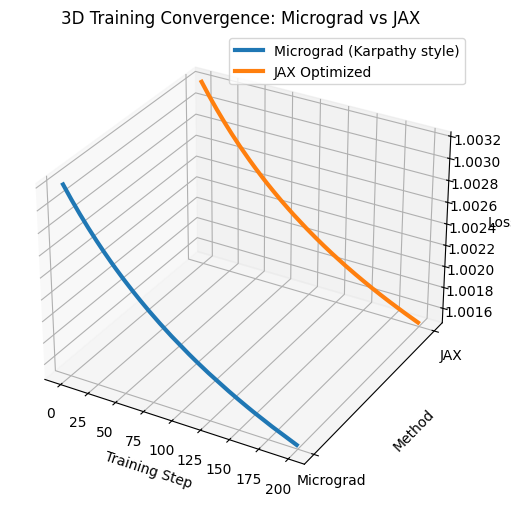

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# convert lists to arrays
loss_plain_np = np.array(loss_plain)
loss_jax_np = np.array(loss_jax)

steps = np.arange(len(loss_plain_np))

# create mesh for plotting
X = np.concatenate([steps, steps])
Y = np.concatenate([np.zeros_like(steps), np.ones_like(steps)])
Z = np.concatenate([loss_plain_np, loss_jax_np])

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

# plot micrograd path
ax.plot(steps, np.zeros_like(steps), loss_plain_np,
        label="Micrograd (Karpathy style)", linewidth=3)

# plot jax path
ax.plot(steps, np.ones_like(steps), loss_jax_np,
        label="JAX Optimized(mine)", linewidth=3)

ax.set_xlabel("Training Step")
ax.set_ylabel("Method")
ax.set_zlabel("Loss")

ax.set_yticks([0,1])
ax.set_yticklabels(["Micrograd", "JAX"])

ax.set_title("3D Training Convergence: Micrograd vs JAX")

ax.legend()

plt.show()

# Micrograd vs Micrograd-JAX

In this notebook we explored two ways of building a minimal neural network training engine inspired by Karpathy's micrograd.

### 1. Karpathy-style Micrograd (Conceptual approach)

The original micrograd implementation builds a small automatic differentiation engine from scratch.  
Every mathematical operation constructs a computation graph, and gradients are propagated manually using backpropagation.

Key characteristics:

- Automatic differentiation engine implemented manually
- Computation graph built node by node
- Backpropagation logic written explicitly
- Focused on understanding the mechanics of neural networks
- Great for educational purposes

This approach helps learners understand:

- how gradients are calculated
- how backpropagation works
- how neural networks learn internally

However, it is not designed for performance or large-scale training.

---

### 2. Micrograd with JAX (Modern approach)

In the JAX version, we keep the same neural network logic but replace the manual autodiff engine with JAX's automatic differentiation system.

Instead of implementing backpropagation ourselves, we use:

- `jax.grad()` for gradient computation
- `jax.jit()` for just-in-time compilation
- `jax.vmap()` for vectorized operations

Key characteristics:

- No manual gradient engine
- Automatic differentiation handled by JAX
- Compiled execution for faster computation
- Much closer to how modern ML systems operate

This approach focuses on:

- efficiency
- clean code
- leveraging optimized ML infrastructure

# Project Summary

In this project we recreated a minimal neural network training system inspired by Karpathy's micrograd and then rebuilt it using JAX.

### What we implemented

The notebook demonstrates the full machine learning training pipeline:

1. Dataset creation
2. Neural network forward pass
3. Loss computation
4. Automatic gradient calculation
5. Gradient descent optimization
6. Model evaluation and visualization

### Key learning outcomes

Through this implementation we learned:

- how neural networks compute predictions
- how loss functions measure model error
- how gradients guide parameter updates
- how gradient descent optimizes a model
- how modern ML frameworks automate these processes

### Conceptual insight

Both implementations follow the exact same mathematical training process:

Data → Model → Prediction → Loss → Gradient → Parameter Update → Repeat

The difference lies in how the gradients are computed:

- Micrograd builds the gradient engine manually
- JAX uses highly optimized automatic differentiation

### Final takeaway

Rebuilding micrograd with JAX demonstrates how foundational ML concepts translate directly into modern machine learning frameworks. Even large-scale AI systems use the same core ideas—just at a much larger scale and with optimized infrastructure.